# Brain Tumor MRI Classification 
**Classes:** Glioma · Meningioma · No Tumor · Pituitary
gliomaورم في الخلايا الدبقية، غالبًا عدواني وسريع النمو.
Meningioma	ورم في أغشية الدماغ، غالبًا حميد وبطيء النمو.
No Tumor	لا يوجد ورم، دماغ طبيعي.
Pituitary	ورم في الغدة النخامية، يؤثر على الهرمونات.


## 1. Setup & Device

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from PIL import Image, UnidentifiedImageError
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import os, copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. SafeImageFolder — handles `.jpg` / `.jpeg` + corrupt files


In [5]:
class SafeImageFolder(datasets.ImageFolder):
    IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')

    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            sample = self.loader(path)
            if self.transform is not None:
                sample = self.transform(sample)
            if self.target_transform is not None:
                target = self.target_transform(target)
            return sample, target
        except (OSError, UnidentifiedImageError, Exception) as e:
            return self.__getitem__((index + 1) % len(self.samples))

## 3. Crop Black Edges

In [6]:
class CropBlackEdges:
    """Removes black MRI borders by finding the bounding box of non-black pixels."""
    def __init__(self, threshold: int = 10, pad: int = 5):
        self.threshold = threshold
        self.pad = pad

    def __call__(self, img: Image.Image) -> Image.Image:
        gray = np.array(img.convert("L"))
        mask = gray > self.threshold
        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        if not rows.any() or not cols.any():
            return img
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        h, w = gray.shape
        rmin = max(0, rmin - self.pad)
        rmax = min(h, rmax + self.pad)
        cmin = max(0, cmin - self.pad)
        cmax = min(w, cmax + self.pad)
        return img.crop((cmin, rmin, cmax, rmax))

## 4. Data Transforms 

In [8]:
train_transform = transforms.Compose([
    CropBlackEdges(threshold=10, pad=5),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

test_val_transform = transforms.Compose([
    CropBlackEdges(threshold=10, pad=5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

## 5. Load Data & Train / Val Split 

In [9]:
# ── UPDATE THESE PATHS ──────────────────────────────────────────────
train_dir = r"C:/Users/Momen/Downloads/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui\Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui\Epic and CSCR hospital Dataset/Epic and CSCR hospital Dataset/Train"
test_dir  = r"C:/Users/Momen/Downloads/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui\Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui\Epic and CSCR hospital Dataset/Epic and CSCR hospital Dataset/Test"
# ────────────────────────────────────────────────────────────────────

train_full = SafeImageFolder(train_dir, transform=train_transform)
val_full   = SafeImageFolder(train_dir, transform=test_val_transform)
dataset_size = len(train_full)

indices = list(range(dataset_size))
split   = int(np.floor(0.25 * dataset_size))
np.random.seed(42)
np.random.shuffle(indices)

train_indices, val_indices = indices[split:], indices[:split]

train_data = Subset(train_full, train_indices)
val_data   = Subset(val_full,   val_indices)
test_data  = SafeImageFolder(test_dir, transform=test_val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f"Classes : {train_full.classes}")
print(f"Train   : {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']
Train   : 8493 | Val: 2830 | Test: 2643


### Class distribution

In [6]:
def print_distribution(dataset, name):
    if hasattr(dataset, 'dataset') and hasattr(dataset, 'indices'):
        targets = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        targets = dataset.targets
    counts = Counter(targets)
    print(f"--- {name} Distribution ---")
    for class_idx, count in sorted(counts.items()):
        print(f"  {train_full.classes[class_idx]}: {count}")

print_distribution(train_data, "Train")
print_distribution(val_data,   "Validation")
print_distribution(test_data,  "Test")

--- Train Distribution ---
  glioma: 2962
  meningioma: 1794
  notumor: 1658
  pituitary: 2079
--- Validation Distribution ---
  glioma: 1007
  meningioma: 626
  notumor: 537
  pituitary: 660
--- Test Distribution ---
  glioma: 864
  meningioma: 586
  notumor: 528
  pituitary: 665


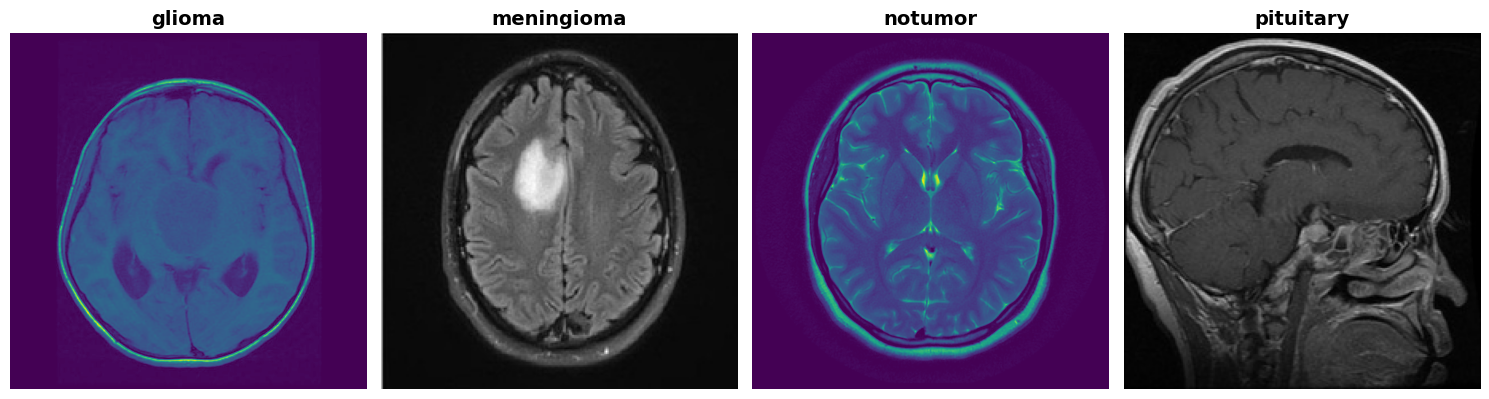

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(train_full.classes), figsize=(15, 5))
displayed_classes = set()
for path, label_idx in train_full.samples:
    if len(displayed_classes) == len(train_full.classes):
        break
    if label_idx not in displayed_classes:
        displayed_classes.add(label_idx)
        img = Image.open(path)
        ax = axes[label_idx]
        ax.imshow(img)
        ax.set_title(train_full.classes[label_idx], fontsize=14, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

## 6. EfficientNet-B0 — Full Backbone Unfreeze

In [7]:
model = models.efficientnet_b0(weights='DEFAULT')

# ── Unfreeze ALL layers — entire backbone will adapt to MRI data ───
for param in model.parameters():
    param.requires_grad = True   # everything trainable

# ── Replace classifier head (same as v2) ──────────────────────────
in_features = model.classifier[1].in_features   # 1280 for B0
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 512),
    nn.SiLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, len(train_full.classes)),
)

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)")

Total params    : 4,665,472
Trainable params: 4,665,472  (100.0%)


## 7. Loss, Optimiser & Scheduler

**Three-tier learning rates:**
- Early backbone blocks (low-level: edges, textures) → `1e-5` — almost frozen, just nudged
- Late backbone blocks (high-level: shapes, structures) → `3e-5` — slightly more freedom
- Classifier head (learning from scratch) → `1e-3` — fast learning

This gradient is called **discriminative fine-tuning** — earlier layers need less updating  
because edge/texture features transfer well from ImageNet; later layers need more.

In [ ]:
# Class-balanced loss weights
targets_train = [train_full.targets[i] for i in train_indices]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(targets_train),
    y=targets_train,
)
weights   = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

all_blocks     = list(model.features.children())  
early_blocks   = all_blocks[:5]                   
late_blocks    = all_blocks[5:]                   

early_params      = [p for block in early_blocks for p in block.parameters()]
late_params       = [p for block in late_blocks  for p in block.parameters()]
classifier_params = list(model.classifier.parameters())

optimizer = optim.AdamW(   
    [
        {'params': early_params,      'lr': 1e-5},   # early backbone
        {'params': late_params,       'lr': 3e-5},   # late backbone  
        {'params': classifier_params, 'lr': 1e-3},   # head          
    ],
    weight_decay=1e-4,
)

epochs    = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-7
)

print("Class weights:", {train_full.classes[i]: round(w, 3) for i, w in enumerate(class_weights)})
print(f"Early backbone params : {sum(p.numel() for p in early_params):,}")
print(f"Late  backbone params : {sum(p.numel() for p in late_params):,}")
print(f"Classifier params     : {sum(p.numel() for p in classifier_params):,}")

Class weights: {'glioma': np.float64(0.717), 'meningioma': np.float64(1.184), 'notumor': np.float64(1.281), 'pituitary': np.float64(1.021)}
Early backbone params : 308,660
Late  backbone params : 3,698,888
Classifier params     : 657,924


## 8. Early Stopping 

In [9]:
class EarlyStopping:
    """Stops training when val loss stops improving for `patience` epochs."""
    def __init__(self, patience: int = 7, min_delta: float = 1e-4,
                 restore_best: bool = True):
        self.patience     = patience
        self.min_delta    = min_delta
        self.restore_best = restore_best
        self.counter      = 0
        self.best_loss    = float('inf')
        self.best_weights = None
        self.stop         = False

    def __call__(self, val_loss: float, model: nn.Module):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.counter      = 0
            if self.restore_best:
                self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            print(f"  EarlyStopping: no improvement {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
                if self.restore_best and self.best_weights is not None:
                    model.load_state_dict(self.best_weights)
                    print("  → Best weights restored.")

early_stopping = EarlyStopping(patience=7, restore_best=True)

## 9. Training Loop 

In [10]:
train_losses     = []
val_losses       = []
train_accuracies = []
val_accuracies   = []

for epoch in range(epochs):
    # ── Training ─────────────────────────────────────────────────────
    model.train()
    total_train_loss, correct_train, total_train = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train  += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc      = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ── Validation ───────────────────────────────────────────────────
    model.eval()
    total_val_loss, correct_val, total_val = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val    += labels.size(0)
            correct_val  += (predicted == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc      = 100 * correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()
    current_lr = optimizer.param_groups[2]['lr']   # show head LR

    print(f"\nEpoch {epoch+1}/{epochs} | Head LR: {current_lr:.6f}")
    print(f"  Train  Loss: {avg_train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"  Val    Loss: {avg_val_loss:.4f} | Acc: {val_acc:.2f}%")

    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\n⛔ Early stopping at epoch {epoch+1}.")
        break

print("\n✅ Training complete.")


Epoch 1/30 | Head LR: 0.000997
  Train  Loss: 0.6481 | Acc: 74.57%
  Val    Loss: 0.4400 | Acc: 82.51%

Epoch 2/30 | Head LR: 0.000989
  Train  Loss: 0.4398 | Acc: 82.76%
  Val    Loss: 0.2629 | Acc: 89.19%

Epoch 3/30 | Head LR: 0.000976
  Train  Loss: 0.3434 | Acc: 87.08%
  Val    Loss: 0.1911 | Acc: 92.12%

Epoch 4/30 | Head LR: 0.000957
  Train  Loss: 0.2991 | Acc: 89.04%
  Val    Loss: 0.3752 | Acc: 92.40%
  EarlyStopping: no improvement 1/7

Epoch 5/30 | Head LR: 0.000933
  Train  Loss: 0.2546 | Acc: 90.10%
  Val    Loss: 0.1391 | Acc: 95.05%

Epoch 6/30 | Head LR: 0.000905
  Train  Loss: 0.2198 | Acc: 91.71%
  Val    Loss: 0.1002 | Acc: 96.25%

Epoch 7/30 | Head LR: 0.000872
  Train  Loss: 0.1860 | Acc: 92.83%
  Val    Loss: 0.0921 | Acc: 96.25%

Epoch 8/30 | Head LR: 0.000835
  Train  Loss: 0.1735 | Acc: 93.24%
  Val    Loss: 0.0809 | Acc: 96.75%

Epoch 9/30 | Head LR: 0.000794
  Train  Loss: 0.1676 | Acc: 93.51%
  Val    Loss: 0.0694 | Acc: 97.17%

Epoch 10/30 | Head LR: 0.00

## 10. Learning Curves

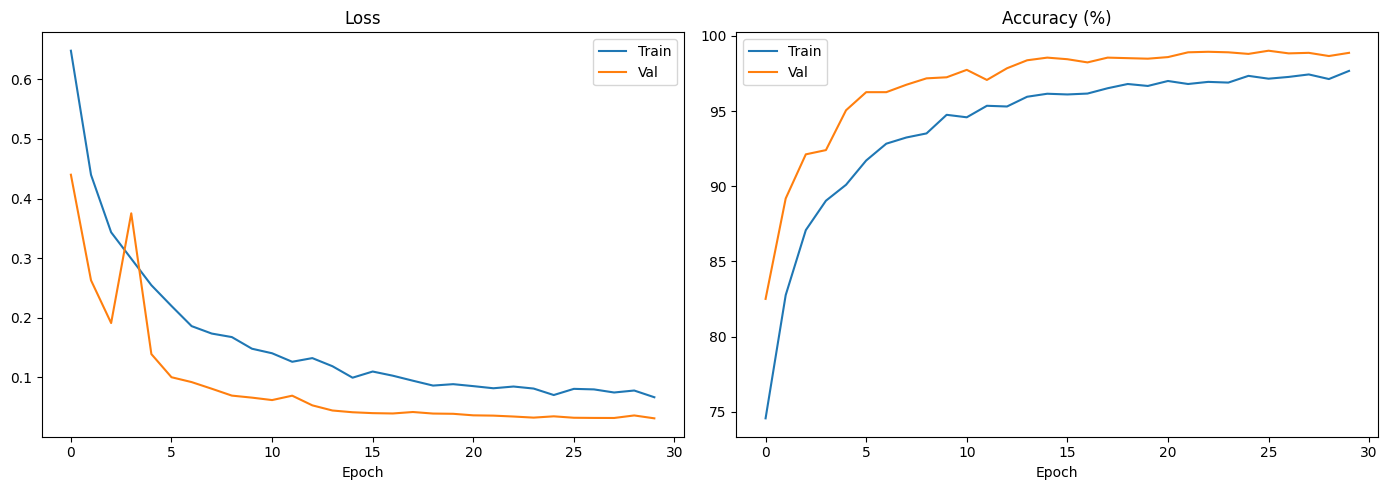

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(train_accuracies, label='Train')
axes[1].plot(val_accuracies,   label='Val')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Evaluation — F1 Score & Confusion Matrix
Watch glioma recall and meningioma precision specifically — those were the weak spots in v2.


=== Validation Results ===
Accuracy : 98.87%
Macro F1 : 0.9886

              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99      1007
  meningioma       0.97      0.98      0.98       626
     notumor       1.00      0.99      0.99       537
   pituitary       0.99      0.99      0.99       660

    accuracy                           0.99      2830
   macro avg       0.99      0.99      0.99      2830
weighted avg       0.99      0.99      0.99      2830



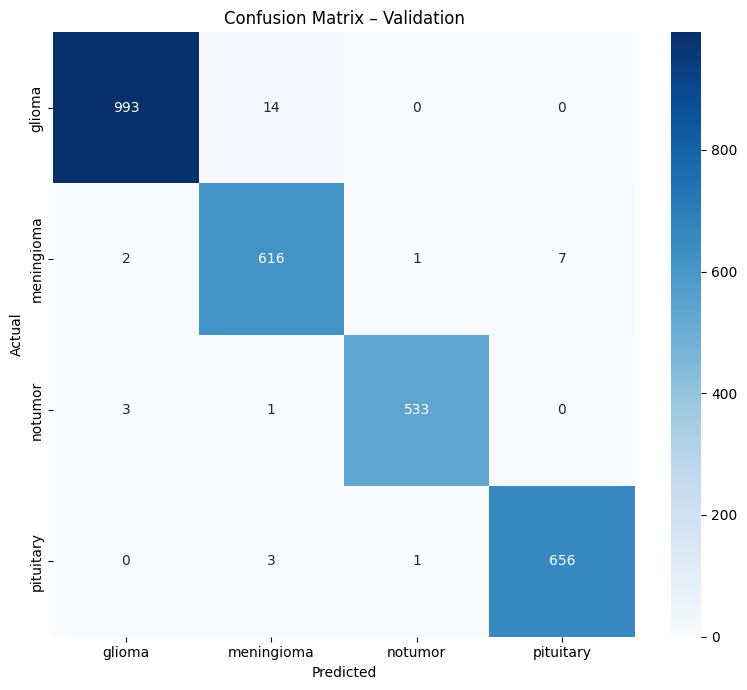


=== Test Results ===
Accuracy : 95.95%
Macro F1 : 0.9606

              precision    recall  f1-score   support

      glioma       0.98      0.90      0.94       864
  meningioma       0.91      0.97      0.94       586
     notumor       0.95      1.00      0.97       528
   pituitary       0.99      1.00      0.99       665

    accuracy                           0.96      2643
   macro avg       0.96      0.97      0.96      2643
weighted avg       0.96      0.96      0.96      2643



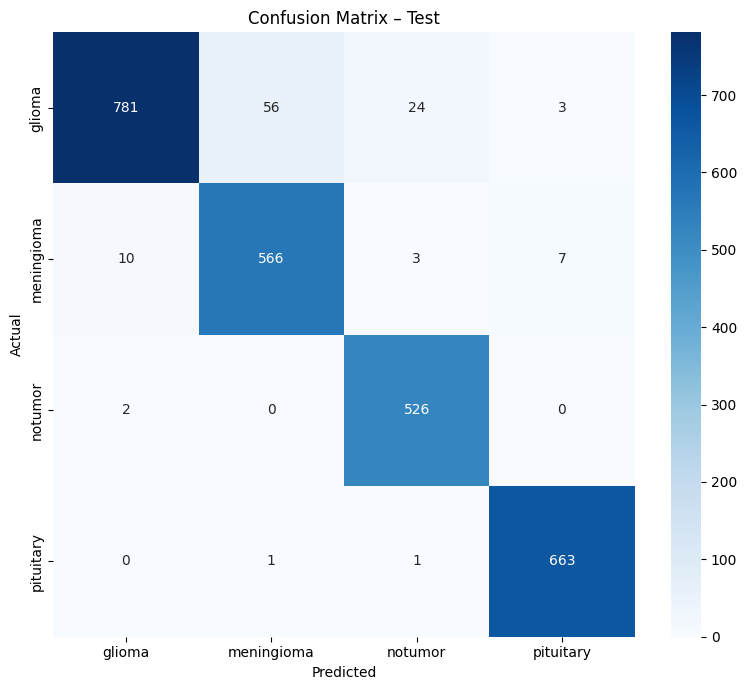

(np.float64(0.9595157018539539), 0.9605708574407618)

In [12]:
def evaluate(loader, split_name='Test'):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"\n=== {split_name} Results ===")
    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Macro F1 : {macro_f1:.4f}")
    print()
    print(classification_report(all_labels, all_preds, target_names=train_full.classes))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=train_full.classes,
                yticklabels=train_full.classes)
    plt.title(f'Confusion Matrix – {split_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return accuracy, macro_f1

evaluate(val_loader,  split_name='Validation')
evaluate(test_loader, split_name='Test')

## 12. Save Model

In [13]:
torch.save(model.state_dict(), 'tumor_efficientnet_v3.pth')
print("✅ Model saved → tumor_efficientnet_v3.pth")

✅ Model saved → tumor_efficientnet_v3.pth


## 13. Single-Image Prediction

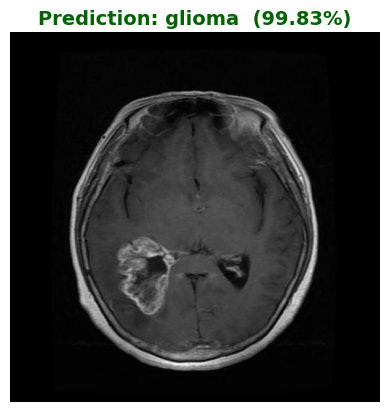

Classification: glioma  |  Confidence: 99.83%


In [35]:
import tkinter as tk
from tkinter import filedialog

def predict_single_image():
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    file_path = filedialog.askopenfilename(
        title="Select Brain MRI Image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.tif *.tiff")]
    )
    if not file_path:
        print("No file selected.")
        return

    predict_transform = transforms.Compose([
        CropBlackEdges(threshold=10, pad=5),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    try:
        img = Image.open(file_path).convert('RGB')
    except (OSError, UnidentifiedImageError) as e:
        print(f"Cannot open image: {e}")
        return

    img_tensor = predict_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs  = F.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    label          = train_full.classes[predicted.item()]
    confidence_pct = confidence.item() * 100

    plt.imshow(img)
    plt.title(f"Prediction: {label}  ({confidence_pct:.2f}%)",
              fontsize=14, color='darkgreen', fontweight='bold')
    plt.axis('off')
    plt.show()
    print(f"Classification: {label}  |  Confidence: {confidence_pct:.2f}%")

predict_single_image()